In [1]:
# enchanced postprocessing script for calculating density raster
# written by Elina, with the help from copilot

import xarray as xr
import shapely
import dask.array as da
import numpy as np
import geopandas as gpd
from pyproj import CRS, transformer

# CRSs
WGS84 = CRS('epsg:4326')  # WGS84
ETRS89UTM = CRS('epsg:25834') # ETRS89 / UTM zone 34N

In [2]:
infol = '/scratch/project_2018610/opendrift_outputs/'
outfol = '/scratch/project_2018610/connectivity/rasters/'

# set opendrift output file name

# this script works in jupyterlab with these files:
#ncfile = 'test_seeding_2500_every_third_day_region_1_2017_test.nc'
ncfile = 'test_seeding_2500_every_third_day_region_1_2018_test.nc'

## but for example this file is too big and sjoin requires too much memory
#ncfile = 'test_seeding_5000_every_third_day_region_1_2012_test.nc'

# set raster file name, netcdf
raster_nc = ncfile.replace('.nc','_uniqsum_raster.nc')
# set raster file name, tif
raster_tif = raster_nc.replace('.nc','.tif')

In [3]:
# load opendrift output
#ds = xr.open_dataset(ncfile, chunks={'trajectory': 100})
ds = xr.open_dataset(infol+ncfile, chunks={})
ds = ds.chunk({'trajectory': 100})
# ds.lon(trajectory, time), ds.lat(trajectory, time)

# extract lon and lat and flatten
lon = ds.lon.data.reshape(-1)
lat = ds.lat.data.reshape(-1)

In [4]:
# vectorized Shapely point constructor
def make_points(lon_arr, lat_arr):
    return shapely.points(lon_arr, lat_arr)

# apply with dask
points = da.map_blocks(
    make_points,
    lon, lat,
    dtype=object
)

In [5]:
# extract and flatten needed variables from opendrift output
status = ds.status.data.reshape(-1)
age = ds.age_seconds.data.reshape(-1)/60./60.  # seconds --> hours
z = ds.z.data.reshape(-1)
origin = ds.origin_marker.data.reshape(-1)

# trajectory and time indices
traj_index = np.repeat(ds.trajectory.values, ds.time.size)+1
time_index = np.tile(ds.time.values, ds.trajectory.size)

In [6]:
# compute geometry and and other variables for geodataframe
geom = points.compute()
status_v = status.compute()
age_v = age.compute()
z_v = z.compute()
origin_v = origin.compute()
traj_v = traj_index
time_v = time_index

In [7]:
# build geodataframe
coords = gpd.GeoDataFrame(
    {
        "traj": traj_v,
        "time": time_v,
        "status": status_v,
        "age_hours": age_v,
        "z": z_v,
        "origin_marker": origin_v,
    },
    geometry=geom,
    crs="EPSG:4326"
)

In [8]:
# check what was created
coords

,traj,time,status,age_hours,z,origin_marker,geometry
0,1,2018-06-01 00:00:00,0.0,0.0,-5.0,0.0,POINT (19.3341 60.60668)
1,1,2018-06-01 01:00:00,0.0,1.0,-5.0,0.0,POINT (19.33584 60.60675)
2,1,2018-06-01 02:00:00,0.0,2.0,-5.0,0.0,POINT (19.33748 60.60684)
3,1,2018-06-01 03:00:00,0.0,3.0,-5.0,0.0,POINT (19.33903 60.60696)
4,1,2018-06-01 04:00:00,0.0,4.0,-5.0,0.0,POINT (19.34048 60.60709)
...,...,...,...,...,...,...,...
1627495,7500,2018-06-09 20:00:00,0.0,68.0,-5.0,2.0,POINT (20.4912 60.92561)
1627496,7500,2018-06-09 21:00:00,0.0,69.0,-5.0,2.0,POINT (20.49377 60.92617)
1627497,7500,2018-06-09 22:00:00,0.0,70.0,-5.0,2.0,POINT (20.49651 60.92671)
1627498,7500,2018-06-09 23:00:00,0.0,71.0,-5.0,2.0,POINT (20.49942 60.92723)


In [9]:
# read grid file (grid must be stored as polygons),
# this is now a test grid I just created, with a resolution of 0.05 degrees,
# we need to decide what resolution to use and prepare the final grid accordingly
gridfile = '/projappl/project_2018610/data/grids/test_grid_0.05deg.gpkg'
grid = gpd.read_file(gridfile)

In [10]:
# check
grid

,gridid,c_coords,geometry
0,1,POINT (17.0804 59.84151),"POLYGON ((17.1054 59.81651, 17.0554 59.81651, ..."
1,2,POINT (17.0804 59.89151),"POLYGON ((17.1054 59.86651, 17.0554 59.86651, ..."
2,3,POINT (17.0804 59.94151),"POLYGON ((17.1054 59.91651, 17.0554 59.91651, ..."
3,4,POINT (17.0804 59.99151),"POLYGON ((17.1054 59.96651, 17.0554 59.96651, ..."
4,5,POINT (17.0804 60.04151),"POLYGON ((17.1054 60.01651, 17.0554 60.01651, ..."
...,...,...,...
7733,7734,POINT (22.3304 63.24151),"POLYGON ((22.3554 63.21651, 22.3054 63.21651, ..."
7734,7735,POINT (22.3304 63.29151),"POLYGON ((22.3554 63.26651, 22.3054 63.26651, ..."
7735,7736,POINT (22.3304 63.34151),"POLYGON ((22.3554 63.31651, 22.3054 63.31651, ..."
7736,7737,POINT (22.3304 63.39151),"POLYGON ((22.3554 63.36651, 22.3054 63.36651, ..."


In [11]:
# spatial join on grid and trajectory dataframes
df = gpd.sjoin(grid, coords)
# count unique trajectories passing each grid cell
nunique = df.groupby('gridid')['traj'].nunique()


#testing if I can use a 'probability'
#nunique = df.groupby('gridid')['traj'].nunique()/df['traj'].max()

# merge the resulting geoseries with original grid dataframe
unique = grid.merge(nunique, how='left', left_on='gridid', right_index=True)
# rename column
unique.rename(columns = {'traj':'N_count'}, inplace = True)

In [12]:
unique

,gridid,c_coords,geometry,N_count
0,1,POINT (17.0804 59.84151),"POLYGON ((17.1054 59.81651, 17.0554 59.81651, ...",NaN
1,2,POINT (17.0804 59.89151),"POLYGON ((17.1054 59.86651, 17.0554 59.86651, ...",NaN
2,3,POINT (17.0804 59.94151),"POLYGON ((17.1054 59.91651, 17.0554 59.91651, ...",NaN
3,4,POINT (17.0804 59.99151),"POLYGON ((17.1054 59.96651, 17.0554 59.96651, ...",NaN
4,5,POINT (17.0804 60.04151),"POLYGON ((17.1054 60.01651, 17.0554 60.01651, ...",NaN
...,...,...,...,...
7733,7734,POINT (22.3304 63.24151),"POLYGON ((22.3554 63.21651, 22.3054 63.21651, ...",NaN
7734,7735,POINT (22.3304 63.29151),"POLYGON ((22.3554 63.26651, 22.3054 63.26651, ...",NaN
7735,7736,POINT (22.3304 63.34151),"POLYGON ((22.3554 63.31651, 22.3054 63.31651, ...",NaN
7736,7737,POINT (22.3304 63.39151),"POLYGON ((22.3554 63.36651, 22.3054 63.36651, ...",NaN


In [13]:
# prepare output to be saved
# set nans to zero:
output = unique.fillna(0)
# change grid cell center coordinates to geometry
# (this part depends on the grid file, and the following works with the test grid files Elina made)
output['geometry'] = output['c_coords'].apply(shapely.wkt.loads)

# saving to netcdf - we probably need only this
# get center coordinates to be used as indices in xarray
output['x'] = output.geometry.x
output['y'] = output.geometry.y
# convert to xarray
da = output.set_index(['y', 'x']).N_count.to_xarray()
print('...check if nans in output: {}'.format(np.isnan(da.data).any()))
# save to netcdf
print('...saving to '+outfol+raster_nc)
da.to_netcdf(outfol+raster_nc)

...check if nans in output: False
...saving to /scratch/project_2018610/connectivity/rasters/test_seeding_2500_every_third_day_region_1_2018_test_uniqsum_raster.nc


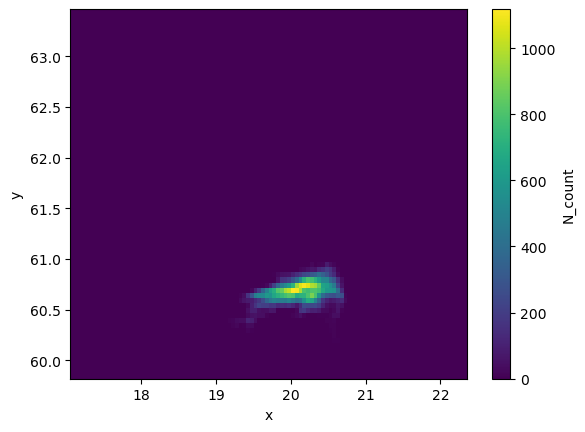

In [14]:
d = xr.open_dataset(outfol+raster_nc)
d.N_count.plot()